In [2]:
#! Task 3A paths, source-only preflight and configuration provenance
import hashlib
import json
import random
import sys
import time

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from google.colab import drive
from IPython.display import display
from torchvision import models

drive.mount('/content/drive')
SEED = 6304
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = False

ROOT = Path('/content/drive/MyDrive/pa1-beyond-iid')
PACS_DIR = ROOT / 'data/pacs'
SHARED_DIR = ROOT / 'shared'
SPLIT_PATH = SHARED_DIR / 'splits/pacs_sketch_seed6304.json'
TASK2 = ROOT / 'task2'
TASK3 = ROOT / 'task3'
METHOD_DIR = TASK3 / 'methods'
MODEL_DIR = TASK3 / 'models'
CONFIG_DIR = TASK3 / 'configs'
RESULT_DIR = TASK3 / 'results/dan_dg'
BASE_PATH = TASK2 / 'configs/base.json'
ERM_RUN_PATH = TASK2 / 'configs/source_only.json'
INITIAL_PATH = TASK2 / 'models/resnet18_initial_seed6304.pt'
ERM_BEST_PATH = TASK2 / 'models/source_only_best.pt'
ERM_LAST_PATH = TASK2 / 'models/source_only_last.pt'
DAN_FILE = TASK2 / 'methods/dan.py'
METHOD_FILE = METHOD_DIR / 'dan_dg.py'
RUN_CONFIG_PATH = CONFIG_DIR / 'dan_dg.json'
BEST_PATH = MODEL_DIR / 'dan_dg_best.pt'
LAST_PATH = MODEL_DIR / 'dan_dg_last.pt'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SOURCE_DOMAINS = ['photo', 'art_painting', 'cartoon']

def sha256(path):
    digest = hashlib.sha256()

    with open(path, 'rb') as stream:
        for chunk in iter(lambda: stream.read(4 * 1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

required_source_only = [
    PACS_DIR / 'pacs_sources.tar', PACS_DIR / 'source_train.csv',
    PACS_DIR / 'source_val.csv', SHARED_DIR / 'pacs.py',
    SHARED_DIR / 'pacs_training.py', SPLIT_PATH, BASE_PATH,
    ERM_RUN_PATH, INITIAL_PATH, ERM_BEST_PATH, ERM_LAST_PATH, DAN_FILE
]

missing = [str(path) for path in required_source_only if not path.is_file()]

if missing:
    raise FileNotFoundError('Finish Task 2A, 2B and the Task 2C method-setup cell first. Missing: ' + str(missing))

base = json.loads(BASE_PATH.read_text())
erm_run = json.loads(ERM_RUN_PATH.read_text())
split = json.loads(SPLIT_PATH.read_text())

if (base['seed'] != SEED or split['seed'] != SEED
        or base['source_domains'] != SOURCE_DOMAINS
        or erm_run['base_config_sha256'] != sha256(BASE_PATH)
        or erm_run['source_split_sha256'] != sha256(SPLIT_PATH)
        or erm_run['initial_checkpoint_sha256'] != sha256(INITIAL_PATH)):
    raise RuntimeError('Locked source protocol / ERM initialization does not match')

erm_last = torch.load(ERM_LAST_PATH, map_location='cpu', weights_only=True)
erm_best = torch.load(ERM_BEST_PATH, map_location='cpu', weights_only=True)

if (not erm_last['finished'] or erm_best['method'] != 'source_only_erm'
        or erm_best['run_config_sha256'] != sha256(ERM_RUN_PATH)
        or erm_best['initial_checkpoint_sha256'] != sha256(INITIAL_PATH)
        or erm_best['epoch'] != erm_last['best_epoch']):
    raise RuntimeError('ERM must be completed and checkpoint provenance must agree before Task 3')

LABEL_NAMES = base['class_names']

if len(LABEL_NAMES) != 7:
    raise RuntimeError('Expected seven PACS classes')

for folder in (METHOD_DIR, MODEL_DIR, CONFIG_DIR, RESULT_DIR):
    folder.mkdir(parents=True, exist_ok=True)

print('Device:', DEVICE, '| use T4 GPU for training')
print('ERM baseline ready, best epoch:', erm_best['epoch'])
print('Task 3 output namespace:', TASK3)
print('Only source-side files read. Task 2 files will not be overwritten.')

Mounted at /content/drive
Device: cuda | use T4 GPU for training
ERM baseline ready, best epoch: 9
Task 3 output namespace: /content/drive/MyDrive/pa1-beyond-iid/task3
Only source-side files read. Task 2 files will not be overwritten.


In [3]:
#! Reuse source-only data loading; verify exact split IDs and domain-balanced batches
sys.path.insert(0, str(SHARED_DIR))

from pacs import make_loaders, set_seed, freeze_bn_running_stats
from pacs_training import (set_epoch_loaders, evaluate_sources,
                           atomic_torch_save, cpu_state_dict)

LOCAL_ROOT = Path('/content/pacs_task3a_sources_only')

if (LOCAL_ROOT / 'images/sketch').exists():
    raise RuntimeError('Use a fresh Task 3A runtime: local folder unexpectedly contains target images')

source_loaders, val_loaders = make_loaders(
    PACS_DIR, LOCAL_ROOT, include_target=False, workers=2
)

train_manifest = pd.read_csv(PACS_DIR / 'source_train.csv')
val_manifest = pd.read_csv(PACS_DIR / 'source_val.csv')

if set(train_manifest['hf_index']) & set(val_manifest['hf_index']):
    raise RuntimeError('Source train/validation overlap')

for domain in SOURCE_DOMAINS:
    expected_train = set(split['source_splits'][domain]['train_indices'])
    expected_val = set(split['source_splits'][domain]['val_indices'])
    observed_train = set(train_manifest.loc[train_manifest.domain == domain, 'hf_index'])
    observed_val = set(val_manifest.loc[val_manifest.domain == domain, 'hf_index'])

    if expected_train != observed_train or expected_val != observed_val:
        raise RuntimeError('Source split changed for ' + domain)
    loader = source_loaders[domain]

    if loader.batch_size != 8 or not loader.drop_last or len(loader) == 0:
        raise RuntimeError('Incorrect 8-image source batch protocol for ' + domain)

    print(f'{domain}: {len(loader.dataset)} train, {len(val_loaders[domain].dataset)} validation')

STEPS = max(len(loader) for loader in source_loaders.values())

if STEPS != erm_run['steps_per_source_epoch']:
    raise RuntimeError('Epoch length differs from original ERM run')

print('Updates per epoch:', STEPS, '| source batch: 8 + 8 + 8 = 24')
print('Target loader requested: NO; target archive extracted: NO')

photo: 1336 train, 334 validation
art_painting: 1638 train, 410 validation
cartoon: 1875 train, 469 validation
Updates per epoch: 234 | source batch: 8 + 8 + 8 = 24
Target loader requested: NO; target archive extracted: NO


In [4]:
#! Evaluate frozen ERM checkpoint on the three allowed source validation domains
set_seed(SEED)
erm_model = models.resnet18(weights=None)
erm_model.fc = nn.Linear(erm_model.fc.in_features, 7)
erm_model.load_state_dict(erm_best['model_state_dict'], strict=True)
erm_model = erm_model.to(DEVICE)
erm_validation = evaluate_sources(erm_model, val_loaders, DEVICE, num_classes=7)

erm_table = pd.DataFrame(
    [{'domain': d, **erm_validation[d]} for d in SOURCE_DOMAINS] +
    [{'domain': 'mean', 'accuracy': erm_validation['mean_accuracy'],
      'macro_f1': erm_validation['mean_macro_f1']},
     {'domain': 'worst', 'accuracy': erm_validation['worst_source_accuracy'],
      'macro_f1': erm_validation['worst_source_macro_f1']}]
)

erm_table.to_csv(TASK3 / 'results/erm_baseline_source.csv', index=False)
(TASK3 / 'results/erm_baseline_provenance.json').write_text(json.dumps({
    'checkpoint_sha256': sha256(ERM_BEST_PATH),
    'checkpoint_path': str(ERM_BEST_PATH),
    'best_epoch': erm_best['epoch'],
    'mean_source_macro_f1': erm_validation['mean_macro_f1'],
    'target_evaluation': 'DEFERRED_TO_TASK3D'
}, indent=2))

print('Existing ERM checkpoint reused without retraining:')

display(erm_table.round(4))
del erm_model

Existing ERM checkpoint reused without retraining:


,domain,accuracy,macro_f1,loss,n_images
0,photo,0.9760,0.9726,0.0606,334.0
1,art_painting,0.9122,0.9136,0.3011,410.0
2,cartoon,0.9488,0.9524,0.2133,469.0
3,mean,0.9457,0.9462,NaN,NaN
4,worst,0.9122,0.9136,NaN,NaN


In [5]:
#! New Task 3-specific method; reuse Task 2 DAN MMD without modifying it
METHOD_SOURCE = r'''#! DAN-DG: source-only pairwise alignment, using the unchanged Task 2 MMD
import torch
import torch.nn.functional as F

from dan import multi_kernel_mmd2

SOURCE_PAIRS = ((0, 1), (0, 2), (1, 2))


def forward_features_logits(model, images):
    #! ResNet-18 pooled 512-D representation immediately before its classifier.
    x = model.conv1(images)
    x = model.bn1(x)
    x = model.relu(x)
    x = model.maxpool(x)
    x = model.layer1(x)
    x = model.layer2(x)
    x = model.layer3(x)
    x = model.layer4(x)
    features = torch.flatten(model.avgpool(x), 1)
    return features, model.fc(features)


def dan_dg_objective(features, logits, labels, lambda_dg=1.0):
    #! Images ordered in groups of 8: Photo, Art Painting, Cartoon.

    if features.shape != (24, 512) or logits.shape != (24, 7) or labels.shape != (24,):
        raise ValueError('Expected [24,512] features, [24,7] logits and 24 source labels')

    groups = (features[:8], features[8:16], features[16:24])
    ce = F.cross_entropy(logits, labels)
    penalties = [multi_kernel_mmd2(groups[i], groups[j]) for i, j in SOURCE_PAIRS]
    pairwise_mmd = torch.stack(penalties).mean()
    return ce + float(lambda_dg) * pairwise_mmd, ce, pairwise_mmd, penalties
'''
if METHOD_FILE.is_file() and METHOD_FILE.read_text() != METHOD_SOURCE:
    raise RuntimeError('Existing Task 3 DAN-DG module differs; inspect rather than overwrite: ' + str(METHOD_FILE))

if not METHOD_FILE.is_file():
    METHOD_FILE.write_text(METHOD_SOURCE)

#! Import only the proven Task 2 loss and the new uniquely named Task 3 module.
METHOD2_DIR = TASK2 / 'methods'
sys.path.insert(0, str(METHOD2_DIR))
sys.path.insert(0, str(METHOD_DIR))

from dan import multi_kernel_mmd2
from dan_dg import forward_features_logits, dan_dg_objective

#! Test pooled features against torchvision's original forward method.
probe = models.resnet18(weights=None)
probe.fc = nn.Linear(probe.fc.in_features, 7)
probe.eval()

with torch.no_grad():
    tiny = torch.randn(2, 3, 64, 64)
    features, logits = forward_features_logits(probe, tiny)
    reference_logits = probe(tiny)

if features.shape != (2, 512) or not torch.allclose(logits, reference_logits, atol=1e-6):
    raise RuntimeError('Feature-extraction path does not match official ResNet-18')
del probe, tiny, features, logits, reference_logits

#! Test exact arithmetic against THREE calls to Task 2's saved MMD routine.
test_features = torch.randn(24, 512, requires_grad=True)
test_logits = torch.randn(24, 7, requires_grad=True)
test_labels = torch.arange(24) % 7
loss, ce, penalty, pairs = dan_dg_objective(test_features, test_logits, test_labels)
reference_mmd = (multi_kernel_mmd2(test_features[:8], test_features[8:16]) +
                 multi_kernel_mmd2(test_features[:8], test_features[16:24]) +
                 multi_kernel_mmd2(test_features[8:16], test_features[16:24])) / 3

if (len(pairs) != 3 or not torch.allclose(penalty, reference_mmd, atol=1e-7)
        or not torch.allclose(loss, ce + reference_mmd, atol=1e-7)):
    raise RuntimeError('Three-pair MMD averaging failed')
loss.backward()

if (test_features.grad is None or test_logits.grad is None
        or not torch.isfinite(test_features.grad).all()
        or not torch.isfinite(test_logits.grad).all()
        or test_features.grad.abs().sum().item() == 0):
    raise RuntimeError('DAN-DG gradients failed the synthetic check')

del test_features, test_logits, test_labels, loss, ce, penalty, pairs, reference_mmd

print('Feature equivalence, pairwise MMD reuse, CE and gradients: PASS')
print('Method module:', METHOD_FILE)
print('Original Task 2 DAN method unchanged:', DAN_FILE)

Feature equivalence, pairwise MMD reuse, CE and gradients: PASS
Method module: /content/drive/MyDrive/pa1-beyond-iid/task3/methods/dan_dg.py
Original Task 2 DAN method unchanged: /content/drive/MyDrive/pa1-beyond-iid/task2/methods/dan.py


In [6]:
#! Lock DAN-DG design and initialize or safely resume an independent model
INITIAL_SHA = sha256(INITIAL_PATH)
initial = torch.load(INITIAL_PATH, map_location='cpu', weights_only=True)

if initial['seed'] != SEED or initial['class_names'] != LABEL_NAMES:
    raise RuntimeError('Shared seed / classes differ from the initial checkpoint')

BN_REFERENCE = {k: value.detach().cpu().clone()
                for k, value in initial['model_state_dict'].items()
                if k.endswith(('running_mean', 'running_var', 'num_batches_tracked'))}

LAMBDA_DG = 1.0

RUN_CONFIG = {
    'method': 'dan_dg', 'seed': SEED, 'lambda_dg': LAMBDA_DG,
    'base_config_sha256': sha256(BASE_PATH),
    'source_split_sha256': sha256(SPLIT_PATH),
    'train_manifest_sha256': sha256(PACS_DIR / 'source_train.csv'),
    'val_manifest_sha256': sha256(PACS_DIR / 'source_val.csv'),
    'source_only_config_sha256': sha256(ERM_RUN_PATH),
    'erm_baseline_checkpoint_sha256': sha256(ERM_BEST_PATH),
    'initial_checkpoint_sha256': INITIAL_SHA,
    'pacs_module_sha256': sha256(SHARED_DIR / 'pacs.py'),
    'training_module_sha256': sha256(SHARED_DIR / 'pacs_training.py'),
    'task2_dan_mmd_module_sha256': sha256(DAN_FILE),
    'dan_dg_method_module_sha256': sha256(METHOD_FILE),
    'source_domains': SOURCE_DOMAINS,
    'source_batch_each': 8, 'steps_per_epoch': STEPS,
    'epoch_definition': 'longest source loader once; cycle shorter sources',
    'architecture': 'ImageNet-initialized torchvision ResNet-18, 512-D pre-head features, 7-class fc',
    'loss': 'mean source cross-entropy + lambda * average of three source-source MMD squared',
    'mmd_pairs': ['photo/art_painting', 'photo/cartoon', 'art_painting/cartoon'],
    'mmd_implementation': 'unchanged Task 2 dan.py; biased; sum 3 RBF kernels',
    'mmd_kernel_multipliers': [0.5, 1.0, 2.0],
    'mmd_bandwidth': 'per-pair current-batch median off-diagonal squared distance',
    'optimizer': 'AdamW', 'learning_rate': base['learning_rate'],
    'weight_decay': base['weight_decay'],
    'max_epochs': base['max_source_epochs'],
    'patience': base['early_stopping_patience'],
    'checkpoint_selection': 'mean source-validation macro-F1',
    'batchnorm': 'running stats frozen; affine parameters trainable',
    'precision': 'FP32 (AMP disabled); recorded numerical-stability choice',
    'target_images_loaded': False, 'target_labels_used': False,
    'target_results_used_for_selection': False,
    'final_target_evaluation': 'task3D_only_after_all_decisions_locked',
}

if (RUN_CONFIG['learning_rate'] != erm_run['learning_rate']
        or RUN_CONFIG['weight_decay'] != erm_run['weight_decay']
        or RUN_CONFIG['max_epochs'] != erm_run['max_epochs']
        or RUN_CONFIG['patience'] != erm_run['patience']):
    raise RuntimeError('New run optimizer/epoch policy disagrees with ERM')

if RUN_CONFIG_PATH.is_file():
    if json.loads(RUN_CONFIG_PATH.read_text()) != RUN_CONFIG:
        raise RuntimeError('Existing DAN-DG config differs; preserve checkpoints and inspect before rerunning')
else:
    RUN_CONFIG_PATH.write_text(json.dumps(RUN_CONFIG, indent=2))
RUN_SHA = sha256(RUN_CONFIG_PATH)

set_seed(SEED)
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 7)
model.load_state_dict(initial['model_state_dict'], strict=True)
model = model.to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=RUN_CONFIG['learning_rate'],
                               weight_decay=RUN_CONFIG['weight_decay'])
history = []
best_f1, best_epoch, bad_epochs, start_epoch = -1.0, 0, 0, 1
training_finished = False

if LAST_PATH.is_file():
    last = torch.load(LAST_PATH, map_location='cpu', weights_only=True)

    if last['run_config_sha256'] != RUN_SHA:
        raise RuntimeError('Resume checkpoint belongs to another configuration')

    model.load_state_dict(last['model_state_dict'], strict=True)
    optimizer.load_state_dict(last['optimizer_state_dict'])

    if 'python_rng_state' in last:
        random.setstate(last['python_rng_state'])

    if 'torch_rng_state' in last:
        torch.set_rng_state(last['torch_rng_state'])

    if DEVICE.type == 'cuda' and last.get('cuda_rng_state') is not None:
        torch.cuda.set_rng_state_all(last['cuda_rng_state'])

    history = last['history']
    best_f1, best_epoch, bad_epochs = last['best_f1'], last['best_epoch'], last['bad_epochs']
    start_epoch, training_finished = last['epoch'] + 1, last['finished']

    if not BEST_PATH.is_file():
        raise FileNotFoundError('Resume state exists but best checkpoint is missing')

    if len(history) != last['epoch']:
        raise RuntimeError('Resume history does not match the last completed epoch')

    print('Restored last completed epoch:', last['epoch'], '| complete:', training_finished)
elif BEST_PATH.is_file():
    raise RuntimeError('Best checkpoint exists without last checkpoint; inspect before proceeding')
else:
    print('Starting fresh DAN-DG from shared initialization, NOT trained ERM.')

print('Run config:', RUN_CONFIG_PATH)
print('FP32 mode; AMP not enabled.')

Starting fresh DAN-DG from shared initialization, NOT trained ERM.
Run config: /content/drive/MyDrive/pa1-beyond-iid/task3/configs/dan_dg.json
FP32 mode; AMP not enabled.


In [7]:
#! Independent source-only DAN-DG loop; preserve checkpoint at every complete epoch

def next_or_cycle(iterator, loader):
    try:
        return next(iterator), iterator
    except StopIteration:
        refreshed = iter(loader)
        return next(refreshed), refreshed


def train_dan_dg_epoch(epoch):
    model.train()
    freeze_bn_running_stats(model)
    set_epoch_loaders(source_loaders, epoch, SEED)
    iterators = {domain: iter(source_loaders[domain]) for domain in SOURCE_DOMAINS}

    sums = {'train_total_loss': 0.0, 'train_cls_loss': 0.0,
            'train_alignment_loss': 0.0, 'mmd_photo_art': 0.0,
            'mmd_photo_cartoon': 0.0, 'mmd_art_cartoon': 0.0}

    correct = 0
    domain_correct = {domain: 0 for domain in SOURCE_DOMAINS}

    for step in range(STEPS):
        batches = []
        for domain in SOURCE_DOMAINS:
            batch, iterators[domain] = next_or_cycle(iterators[domain], source_loaders[domain])
            batches.append(batch)

        images = torch.cat([part[0] for part in batches]).to(DEVICE, non_blocking=True)
        labels = torch.cat([part[1] for part in batches]).to(DEVICE, non_blocking=True)

        if images.shape != (24, 3, 224, 224) or labels.shape != (24,):
            raise RuntimeError(f'Unexpected source batch at epoch={epoch}, step={step}')

        optimizer.zero_grad(set_to_none=True)

        #! Full precision throughout forward/CE/MMD/backward; no autocast or GradScaler.
        features, logits = forward_features_logits(model, images)
        loss, cls_loss, penalty, pairs = dan_dg_objective(
            features, logits, labels, lambda_dg=LAMBDA_DG
        )

        if not torch.isfinite(loss).item():
            raise FloatingPointError(
                f'Non-finite DAN-DG loss at epoch={epoch} step={step}: '
                f'features_finite={torch.isfinite(features).all().item()}, '
                f'logits_finite={torch.isfinite(logits).all().item()}, '
                f'CE={cls_loss.detach().item()}, MMD={penalty.detach().item()}'
            )

        loss.backward()

        #! Infinity threshold is a gradient finite-check; it never clips gradients.
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=float('inf'),
                                       error_if_nonfinite=True)
        optimizer.step()

        sums['train_total_loss'] += loss.detach().item()
        sums['train_cls_loss'] += cls_loss.detach().item()
        sums['train_alignment_loss'] += penalty.detach().item()

        for key, component in zip(('mmd_photo_art', 'mmd_photo_cartoon', 'mmd_art_cartoon'), pairs):
            sums[key] += component.detach().item()
        predictions = logits.detach().argmax(dim=1)
        correct += int((predictions == labels).sum().item())

        for index, domain in enumerate(SOURCE_DOMAINS):
            domain_correct[domain] += int((predictions[index*8:index*8+8] ==
                                           labels[index*8:index*8+8]).sum().item())

    metrics = {key: value / STEPS for key, value in sums.items()}

    metrics.update({'train_accuracy': correct / (STEPS*24), 'updates': STEPS,
                    'source_examples_processed': STEPS*24,
                    'target_examples_processed': 0})

    metrics.update({f'train_{domain}_accuracy': domain_correct[domain]/(STEPS*8)
                    for domain in SOURCE_DOMAINS})
    return metrics

if training_finished:
    print('DAN-DG already completed; no retraining.')
else:
    for epoch in range(start_epoch, RUN_CONFIG['max_epochs'] + 1):
        tick = time.perf_counter()
        train_metrics = train_dan_dg_epoch(epoch)
        validation = evaluate_sources(model, val_loaders, DEVICE, num_classes=7)
        score = validation['mean_macro_f1']
        improved = score > best_f1 + 1e-8

        if improved:
            best_f1, best_epoch, bad_epochs = score, epoch, 0
            atomic_torch_save({
                'method': 'dan_dg', 'seed': SEED, 'epoch': epoch,
                'best_source_val_mean_macro_f1': best_f1,
                'source_validation': validation,
                'run_config_sha256': RUN_SHA,
                'initial_checkpoint_sha256': INITIAL_SHA,
                'class_names': LABEL_NAMES,
                'model_state_dict': cpu_state_dict(model)
            }, BEST_PATH)
        else:
            bad_epochs += 1

        row = {
            'epoch': epoch, **train_metrics,
            'mean_source_val_accuracy': validation['mean_accuracy'],
            'mean_source_val_macro_f1': validation['mean_macro_f1'],
            'worst_source_val_accuracy': validation['worst_source_accuracy'],
            'worst_source_val_macro_f1': validation['worst_source_macro_f1'],
            'elapsed_seconds': time.perf_counter() - tick,
        }

        for domain in SOURCE_DOMAINS:
            row[f'val_{domain}_accuracy'] = validation[domain]['accuracy']
            row[f'val_{domain}_macro_f1'] = validation[domain]['macro_f1']
            row[f'val_{domain}_loss'] = validation[domain]['loss']

        history.append(row)
        training_finished = bad_epochs >= RUN_CONFIG['patience'] or epoch == RUN_CONFIG['max_epochs']

        atomic_torch_save({
            'epoch': epoch, 'finished': training_finished,
            'method': 'dan_dg', 'model_state_dict': cpu_state_dict(model),
            'optimizer_state_dict': optimizer.state_dict(),
            'history': history, 'best_epoch': best_epoch, 'best_f1': best_f1,
            'bad_epochs': bad_epochs, 'run_config_sha256': RUN_SHA,
            'python_rng_state': random.getstate(),
            'torch_rng_state': torch.get_rng_state(),
            'cuda_rng_state': torch.cuda.get_rng_state_all() if DEVICE.type == 'cuda' else None,
        }, LAST_PATH)

        pd.DataFrame(history).to_csv(RESULT_DIR / 'history.csv', index=False)
        print(f"Epoch {epoch:02d} | CE {row['train_cls_loss']:.4f} | "
              f"pair MMD² {row['train_alignment_loss']:.4f} | "
              f"source F1 {score:.4f} | best {best_f1:.4f} (epoch {best_epoch}) | "
              f"patience {bad_epochs}/{RUN_CONFIG['patience']} | "
              f"{row['elapsed_seconds']:.1f}s")

        if training_finished:
            break

print('Training finished:', training_finished, '| best epoch:', best_epoch)
print('Best mean source macro-F1:', round(best_f1, 5))

Epoch 01 | CE 1.9412 | pair MMD² 0.5565 | source F1 0.0361 | best 0.0361 (epoch 1) | patience 0/5 | 33.9s
Epoch 02 | CE 1.9808 | pair MMD² 0.5207 | source F1 0.0361 | best 0.0361 (epoch 1) | patience 1/5 | 32.2s
Epoch 03 | CE 1.9374 | pair MMD² 0.5254 | source F1 0.0507 | best 0.0507 (epoch 3) | patience 0/5 | 33.6s
Epoch 04 | CE 1.9307 | pair MMD² 0.5641 | source F1 0.0507 | best 0.0507 (epoch 3) | patience 1/5 | 35.7s
Epoch 05 | CE 1.9319 | pair MMD² 0.5222 | source F1 0.0507 | best 0.0507 (epoch 3) | patience 2/5 | 36.7s
Epoch 06 | CE 1.9311 | pair MMD² 0.5249 | source F1 0.0507 | best 0.0507 (epoch 3) | patience 3/5 | 34.3s
Epoch 07 | CE 1.9338 | pair MMD² 0.4873 | source F1 0.0507 | best 0.0507 (epoch 3) | patience 4/5 | 33.9s
Epoch 08 | CE 1.9271 | pair MMD² 0.5136 | source F1 0.0507 | best 0.0507 (epoch 3) | patience 5/5 | 33.9s
Training finished: True | best epoch: 3
Best mean source macro-F1: 0.05067


In [8]:
#! Source-only results from the best DAN-DG checkpoint
if not training_finished or not BEST_PATH.is_file():
    raise RuntimeError('Complete DAN-DG training before calculating final source metrics')

best = torch.load(BEST_PATH, map_location='cpu', weights_only=True)

if (best['method'] != 'dan_dg' or best['run_config_sha256'] != RUN_SHA
        or best['initial_checkpoint_sha256'] != INITIAL_SHA):
    raise RuntimeError('Best DAN-DG checkpoint does not match this locked run')

model.load_state_dict(best['model_state_dict'], strict=True)
validation = evaluate_sources(model, val_loaders, DEVICE, num_classes=7)

if not np.isclose(validation['mean_macro_f1'], best['best_source_val_mean_macro_f1'], atol=1e-7):
    raise RuntimeError('Saved best F1 does not match source-only re-evaluation')

source_table = pd.DataFrame(
    [{'domain': d, **validation[d]} for d in SOURCE_DOMAINS] +
    [{'domain': 'mean', 'accuracy': validation['mean_accuracy'],
      'macro_f1': validation['mean_macro_f1']},
     {'domain': 'worst', 'accuracy': validation['worst_source_accuracy'],
      'macro_f1': validation['worst_source_macro_f1']}]
)

source_table.to_csv(RESULT_DIR / 'source_validation.csv', index=False)
comparison = erm_table[['domain', 'accuracy', 'macro_f1']].merge(
    source_table[['domain', 'accuracy', 'macro_f1']], on='domain',
    suffixes=('_erm', '_dan_dg')
)

comparison.to_csv(RESULT_DIR / 'erm_vs_dan_dg_source.csv', index=False)

summary = {
    'method': 'dan_dg', 'seed': SEED, 'lambda_dg': LAMBDA_DG,
    'best_epoch': best['epoch'], 'source_validation': validation,
    'best_source_macro_f1': best['best_source_val_mean_macro_f1'],
    'checkpoint_path': str(BEST_PATH),
    'erm_checkpoint_sha256': sha256(ERM_BEST_PATH),
    'initial_checkpoint_sha256': INITIAL_SHA,
    'target_images_loaded': False, 'target_labels_used': False,
    'target_evaluation': 'DEFERRED_TO_TASK3D',
}

(RESULT_DIR / 'summary.json').write_text(json.dumps(summary, indent=2))
print('DAN-DG source validation:')

display(source_table.round(4))

print('Source-only comparison:')
display(comparison.round(4))

DAN-DG source validation:


,domain,accuracy,macro_f1,loss,n_images
0,photo,0.2575,0.0585,1.9325,334.0
1,art_painting,0.2195,0.0514,1.9368,410.0
2,cartoon,0.1727,0.0421,1.9397,469.0
3,mean,0.2166,0.0507,NaN,NaN
4,worst,0.1727,0.0421,NaN,NaN


Source-only comparison:


,domain,accuracy_erm,macro_f1_erm,accuracy_dan_dg,macro_f1_dan_dg
0,photo,0.9760,0.9726,0.2575,0.0585
1,art_painting,0.9122,0.9136,0.2195,0.0514
2,cartoon,0.9488,0.9524,0.1727,0.0421
3,mean,0.9457,0.9462,0.2166,0.0507
4,worst,0.9122,0.9136,0.1727,0.0421


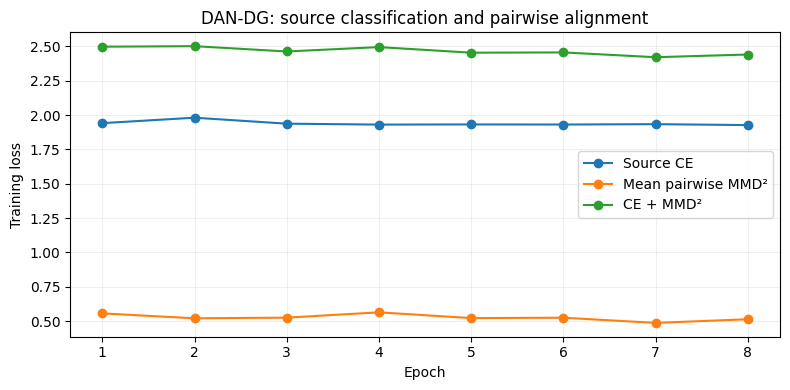

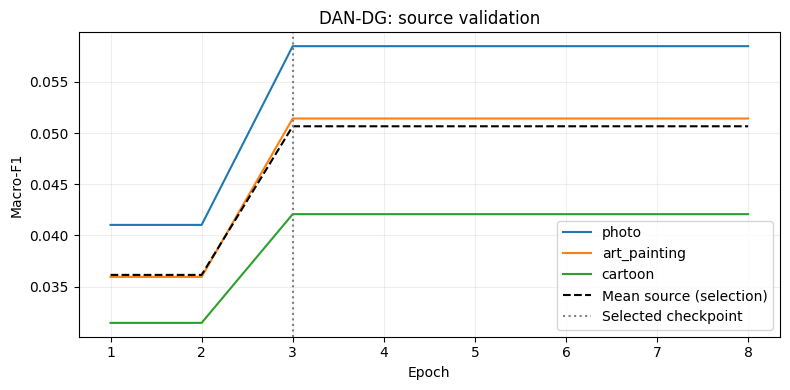

BN audit PASS: 60 buffers unchanged; affine parameters trainable


In [9]:
#! Save report evidence and audit frozen running statistics
history_df = pd.read_csv(RESULT_DIR / 'history.csv')
fig, ax = plt.subplots(figsize=(8, 4))

for column, label in [('train_cls_loss', 'Source CE'),
                      ('train_alignment_loss', 'Mean pairwise MMD²'),
                      ('train_total_loss', 'CE + MMD²')]:
    ax.plot(history_df['epoch'], history_df[column], marker='o', label=label)

ax.set(xlabel='Epoch', ylabel='Training loss', title='DAN-DG: source classification and pairwise alignment')
ax.grid(alpha=0.2)
ax.legend()

fig.tight_layout()
fig.savefig(RESULT_DIR / 'dan_dg_training_losses.png', dpi=220)

plt.show()

fig, ax = plt.subplots(figsize=(8, 4))

for domain in SOURCE_DOMAINS:
    ax.plot(history_df['epoch'], history_df[f'val_{domain}_macro_f1'], label=domain)

ax.plot(history_df['epoch'], history_df['mean_source_val_macro_f1'],
        color='black', linestyle='--', label='Mean source (selection)')
ax.axvline(best_epoch, color='gray', linestyle=':', label='Selected checkpoint')
ax.set(xlabel='Epoch', ylabel='Macro-F1', title='DAN-DG: source validation')
ax.grid(alpha=0.2)
ax.legend()

fig.tight_layout()
fig.savefig(RESULT_DIR / 'dan_dg_source_f1.png', dpi=220)

plt.show()

current = model.state_dict()
mismatches = [key for key, value in BN_REFERENCE.items()
              if not torch.equal(current[key].detach().cpu(), value)]

if mismatches:
    raise RuntimeError('Frozen BatchNorm buffers changed: ' + str(mismatches[:5]))
if not all(layer.weight.requires_grad and layer.bias.requires_grad
           for layer in model.modules() if isinstance(layer, nn.modules.batchnorm._BatchNorm)):
    raise RuntimeError('BatchNorm affine parameters were accidentally frozen')

(RESULT_DIR / 'batchnorm_audit.json').write_text(json.dumps({
    'running_buffers_equal_to_initial': True,
    'buffer_count': len(BN_REFERENCE),
    'affine_trainable': True,
}, indent=2))

print('BN audit PASS:', len(BN_REFERENCE), 'buffers unchanged; affine parameters trainable')

In [10]:
#! Last integrity check; Task 3A outputs only, zero target data use
required = [METHOD_FILE, RUN_CONFIG_PATH, BEST_PATH, LAST_PATH,
            TASK3 / 'results/erm_baseline_source.csv',
            TASK3 / 'results/erm_baseline_provenance.json',
            RESULT_DIR / 'history.csv', RESULT_DIR / 'source_validation.csv',
            RESULT_DIR / 'erm_vs_dan_dg_source.csv', RESULT_DIR / 'summary.json',
            RESULT_DIR / 'batchnorm_audit.json',
            RESULT_DIR / 'dan_dg_training_losses.png',
            RESULT_DIR / 'dan_dg_source_f1.png']

missing = [str(path) for path in required if not path.is_file()]

if missing:
    raise FileNotFoundError('Missing Task 3A artifacts: ' + str(missing))

saved_best = torch.load(BEST_PATH, map_location='cpu', weights_only=True)
saved_last = torch.load(LAST_PATH, map_location='cpu', weights_only=True)
saved_history = pd.read_csv(RESULT_DIR / 'history.csv')
saved_source = pd.read_csv(RESULT_DIR / 'source_validation.csv')

if (not saved_last['finished'] or len(saved_history) != saved_last['epoch']
        or saved_last['best_epoch'] != saved_best['epoch']
        or saved_best['run_config_sha256'] != sha256(RUN_CONFIG_PATH)
        or saved_best['initial_checkpoint_sha256'] != sha256(INITIAL_PATH)
        or not np.isclose(saved_best['best_source_val_mean_macro_f1'],
                          saved_source.loc[saved_source.domain == 'mean', 'macro_f1'].iloc[0], atol=1e-7)):
    raise RuntimeError('DAN-DG checkpoint, history, or source validation disagree')
locked = json.loads(RUN_CONFIG_PATH.read_text())

if any([
    sha256(ERM_BEST_PATH) != locked['erm_baseline_checkpoint_sha256'],
    sha256(DAN_FILE) != locked['task2_dan_mmd_module_sha256'],
    sha256(METHOD_FILE) != locked['dan_dg_method_module_sha256'],
    sha256(SHARED_DIR / 'pacs.py') != locked['pacs_module_sha256'],
    sha256(SHARED_DIR / 'pacs_training.py') != locked['training_module_sha256'],
]):
    raise RuntimeError('A locked upstream dependency changed; inspect before continuing')

print('TASK 3A COMPLETE — DAN-DG')
print('Verified Task 3A artifact files:', len(required))
print('Best epoch:', saved_best['epoch'], '| mean source macro-F1:',
      round(saved_best['best_source_val_mean_macro_f1'], 5))
print('Saved checkpoint:', BEST_PATH)
print('No target images, target labels, or target performance accessed.')

TASK 3A COMPLETE — DAN-DG
Verified Task 3A artifact files: 13
Best epoch: 3 | mean source macro-F1: 0.05067
Saved checkpoint: /content/drive/MyDrive/pa1-beyond-iid/task3/models/dan_dg_best.pt
No target images, target labels, or target performance accessed.
